##### Develop a program to demonstrate the working of Linear Regression and Polynomial Regression. Use California Housing Dataset for Linear Regression and Auto MPG Dataset (for vehicle fuel efficiency prediction) for Polynomial Regression.

## Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

In [2]:
california = fetch_california_housing()
X_california = california.data
y_california = california.target

In [9]:
X_train_california, X_test_california, y_train_california, y_test_california = train_test_split(X_california, y_california, test_size = 0.2, random_state = 42)
linear_model = LinearRegression()
linear_model.fit(X_train_california, y_train_california)
y_pred_california = linear_model.predict(X_test_california)

In [11]:
mse_california = mean_squared_error(y_test_california, y_pred_california)
print(f"Linear Regression Mean Squared Error (California Housing): {mse_california:.2f}")

Linear Regression Mean Squared Error (California Housing): 0.56


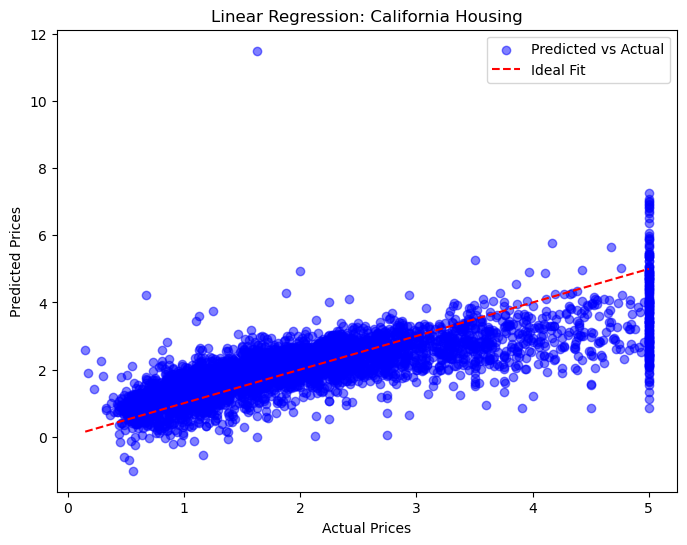

In [29]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test_california, y_pred_california, color = "blue", alpha = 0.5, label = 'Predicted vs Actual')
plt.plot([min(y_test_california), max(y_test_california)],
         [min(y_test_california), max(y_test_california)],
         color = "red", linestyle = "--", label = 'Ideal Fit')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: California Housing")
plt.legend()
plt.show()

## Polynomial Regression

In [41]:
df = pd.read_csv("C:/Users/Devops Lab-B1/Desktop/4CB23CB005/7th_dataset_auto-mpg.csv")

X_auto = df[['displacement', 'weight', 'acceleration']]
y_auto = df['mpg']

In [59]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_auto, y_auto, test_size = 0.2, random_state = 42
)

In [43]:
scaled_a = StandardScaler()

X_train_a_scaled = scaled_a.fit_transform(X_train_a)
X_test_a_scaled = scaled_a.transform(X_test_a)

In [60]:
poly = PolynomialFeatures(degree = 2)

X_train_poly = poly.fit_transform(X_train_a_scaled)
X_test_poly = poly.transform(X_test_a_scaled)

In [61]:
lmodel = LinearRegression()
lmodel.fit(X_train_poly, y_train_a)

y_pred = lmodel.predict(X_test_poly)

In [68]:
poly_mse = mean_squared_error(y_test_a, y_pred)

print(f"Polynomial Regression Mean Squared Error (Auto-MPG Dataset): {poly_mse:.2f}")

Polynomial Regression Mean Squared Error (Auto-MPG Dataset): 11.99


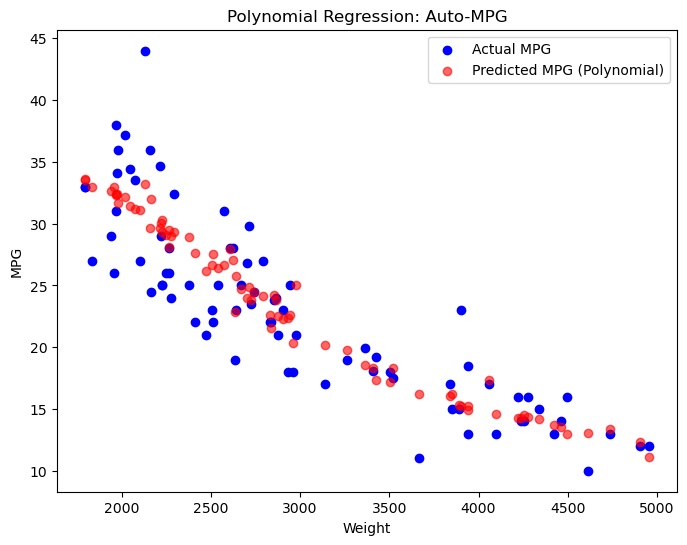

In [75]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test_a['weight'], y_test_a, color = "blue", label = "Actual MPG")
plt.scatter(X_test_a['weight'], y_pred, color = "red", alpha = 0.6, label = "Predicted MPG (Polynomial)")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Polynomial Regression: Auto-MPG")
plt.legend()
plt.show()